# **Error analysis**

## **Navigation**

- [**Basic imports and initialization**](#Basic-imports-and-initialization)
- [**1. ViT-b-16**](#1.-ViT-b-16)
- [**2. Swin-t**](#2.-Swin-t)
- [**3. MaxViT-t**](#3.-MaxViT-t)

## Basic imports and initialization

$\qquad $ [[Back to top]](#Navigation) $\qquad$ [[Next part $\to$]](#1.-Sampling-scheme-1:-Summary-statistics)

- [Setting up templates, limiting the hardware resources, importing packages](#Setting-up-templates,-limiting-the-hardware-resources,-importing-packages)
- [Initializing common variables](#Initializing-common-variables)



### Setting up templates, limiting the hardware resources, importing packages

$\quad$[[Back to section]](#Basic-imports-and-initialization)$\quad$[[Next subsect.$\to$]](#Initializing-common-variables)

In [3]:
notebook_directory_offset = '../'

To provide easy access to modules stored in the ```../src/``` directory, we use the following workaround:

In [4]:
import os
import sys
sys.path.append(
    os.path.join(notebook_directory_offset, '../src/')
)

Next, we limit the hardware usage by setting the configuration dictionaries, maximum number of threads:

In [5]:
# set limitations on hardware
import hardware_setup
hardware_setup.mkl_set_num_threads(num_threads=4)

[mkl]: set up num_threads=4/4


Then we import all necessary packages:

In [6]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import sensitivity_analysis.preprocess_visualize
import sensitivity_analysis.augmentation_setting

import discriminant_analysis.compute
import discriminant_analysis.plot

import prediction.compute

import preparation.single_unit
import preparation.visualize

import data_loader.utils

import error_analysis.retrieve
import error_analysis.plot

### Initializing common variables

[[$\leftarrow$Prev.subsect.]](#Setting-up-templates,-limiting-the-hardware-resources,-importing-packages)$\quad$[[Back to section]](#Basic-imports-and-initialization)$\quad$

In [7]:
activations_dirname = '../results/'
model_dirname = '../torch-models/'
exp_relative_path = '../experiments/'
augmentation_set_numbers_list = (1, 2)

dataset_name = 'imagenet'
#dataset_name = 'places365'
data_dirname = f'../data/{dataset_name}'
values_fnm_base = f'{dataset_name}_values'

save_dirname = os.path.join(
    notebook_directory_offset,
    activations_dirname,
    "errplots"
)

os.makedirs(save_dirname, exist_ok=True)

In [8]:
values_names_list = (
    'rbscc (train)',
    'rbscc (valid)',
    'shpv',
    'si',
    'siT'
)
values_names_list_2 = (
    'shpv',
    'si',
    'siT'
)

values_cov_pairs_dict = {
    'shpv': 'shptv',
    'si': 'sitv',
    'siT': 'sitv'
}
cov_values_names_dict = {
    'sitv': ('var', 'mean'),
    'shptv': ('var', 'mean'),
    #'sitv': 'var',
    #'shptv': 'var',
}
cov_values_funcs = {
    'sitv': {
        'mean': None,
        'var': None,
        ('var', 'mean'): lambda x: sensitivity_analysis.preprocess_visualize.compute_coef_var(x, log=False),
    },
    'shptv': {
        'means': None,
        'var': None,
        ('var', 'mean'): lambda x: sensitivity_analysis.preprocess_visualize.compute_coef_var(x, log=False),
    }
}

shpv_group_indices_dict = {}
for augmentation_set_number in augmentation_set_numbers_list:
    shpv_group_indices_dict[
        augmentation_set_number
    ] = sensitivity_analysis.augmentation_setting.get_group_variables_indices(
        augmentation_set_number,
        use_permutation_variable=True,
        use_class_variable=True,
        use_partition_variable=True
    )

shpv_values_func = lambda x, aug_set: (
    sensitivity_analysis.preprocess_visualize.extract_shp_values_func(
        x, shpv_group_indices_dict[aug_set], clip=False
    )
)

values_names = ('shpv', 'si', 'siT')

Plot the legend:

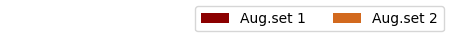

In [9]:
colors = ["darkred", "chocolate"]
fig, ax = error_analysis.plot.generate_legend(
    augmentation_set_numbers_list,
    colors,
    figsize=(5, 0.2)
)
fig.savefig(
    os.path.join(save_dirname, "legend_errplot.pdf"),
    bbox_inches="tight"
)

## 1. ViT-b-16

[[$\leftarrow$ Prev.part]](#Basic-imports-and-initialization) $\qquad$ [[Back to top]](#Navigation) $\qquad$ [[Next part $\to$]](#2.-Swin-t)

- [1.1 Set up network-specific variables](#1.1-Set-up-network-specific-variables)
- [1.2 Sobol indices](#1.2-Sobol-indices)
- [1.3 Shapley values](#1.3-Shapley-values)

### 1.1 Set up network-specific variables

[[Back to top]](#1.-ViT-b-16)

In [10]:
vitb16_network_name = 'vit_b_16'
vitb16_network_modules = [
    'encoder.layers.encoder_layer_2',
    'encoder.layers.encoder_layer_5',
    'encoder.layers.encoder_layer_8',
    'encoder.layers.encoder_layer_11',
    'heads'
]

In [11]:
vitb16_imagenet_values_fnms_dict = preparation.single_unit.extract_massive_values_fnms(
    vitb16_network_name,
    values_fnm_base,
    augmentation_set_numbers_list,
    prefix=None
);



### 1.2 Sobol indices

[[Back to top]](#1.-ViT-b-16)

In [12]:
# load values
vitb16_imagenet_si_variances = error_analysis.retrieve.load_values(
    vitb16_imagenet_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    vitb16_network_modules,
    values_name="var",
    values_key="sitv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
vitb16_imagenet_si_values = error_analysis.retrieve.load_values(
    vitb16_imagenet_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    vitb16_network_modules,
    values_name="si+sT",
    values_key="si",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)

In [13]:
# check that all S_i <= S_i^T
for module_name in vitb16_network_modules:
    for aug_set in augmentation_set_numbers_list:
        c_values = vitb16_imagenet_si_values[module_name][aug_set]
        c_variances = vitb16_imagenet_si_variances[module_name][aug_set][0]
        c_values = np.reshape(c_values, (2, -1) + c_values.shape[1:])
        #print(c_values.shape, c_variances.shape)
        ind_high_sT = np.where(c_values[1] > 1.)
        print(module_name, aug_set, (c_values[0] > c_values[1]).any())

encoder.layers.encoder_layer_2 1 False
encoder.layers.encoder_layer_2 2 False
encoder.layers.encoder_layer_5 1 False
encoder.layers.encoder_layer_5 2 False
encoder.layers.encoder_layer_8 1 False
encoder.layers.encoder_layer_8 2 False
encoder.layers.encoder_layer_11 1 False
encoder.layers.encoder_layer_11 2 False
heads 1 False
heads 2 False


In [14]:
# create grids and compute statistics
vitb16_imagenet_x_si = -np.power(10, np.linspace(-5, -0.5, 100))
vitb16_imagenet_x_sT = 1 + np.power(10, np.linspace(-5, 0., 100))
(
    vitb16_imagenet_y_si,
    vitb16_imagenet_cnt_si,
    vitb16_imagenet_y_sT,
    vitb16_imagenet_cnt_sT,
) = error_analysis.retrieve.retrieve_sobol_outs(
    vitb16_imagenet_si_values,
    vitb16_imagenet_si_variances,
    vitb16_imagenet_x_si,
    vitb16_imagenet_x_sT,
    vitb16_network_modules,
    augmentation_set_numbers_list,
    #eps=1e-5
)

In [16]:
# shorthen the network module names
shorten_vitb16_network_modules = [
    module_name.split('.')[-1] for module_name in vitb16_network_modules
]
for module_name in vitb16_network_modules:
    cmn = module_name.split('.')[-1]
    vitb16_imagenet_y_si[cmn] = vitb16_imagenet_y_si[module_name]
    vitb16_imagenet_cnt_si[cmn] = vitb16_imagenet_cnt_si[module_name]

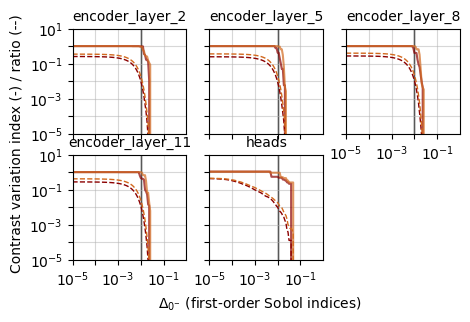

In [17]:
# plots for first-order Sobol indices
fig, ax = error_analysis.plot.plot_first_sobol_outs(
    vitb16_imagenet_x_si,
    vitb16_imagenet_y_si,
    vitb16_imagenet_cnt_si,
    shorten_vitb16_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e0,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "vitb16_imagenet_si_errplot.pdf"),
    bbox_inches="tight"
)

In [18]:
# shorten the network module names
shorten_vitb16_network_modules = [
    module_name.split('.')[-1] for module_name in vitb16_network_modules
]
for module_name in vitb16_network_modules:
    cmn = module_name.split('.')[-1]
    vitb16_imagenet_y_sT[cmn] = vitb16_imagenet_y_sT[module_name]
    vitb16_imagenet_cnt_sT[cmn] = vitb16_imagenet_cnt_sT[module_name]

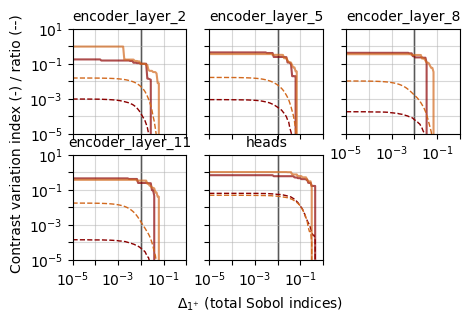

In [19]:
# plots for total Sobol indices
fig, ax = error_analysis.plot.plot_total_sobol_outs(
    vitb16_imagenet_x_sT,
    vitb16_imagenet_y_sT,
    vitb16_imagenet_cnt_sT,
    shorten_vitb16_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e0,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "vitb16_imagenet_sT_errplot.pdf"),
    bbox_inches="tight"
)

### 1.3 Shapley values

[[Back to top]](#1.-ViT-b-16)

In [20]:
# load values
vitb16_imagenet_shpv_values = error_analysis.retrieve.load_values(
    vitb16_imagenet_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    vitb16_network_modules,
    values_name="shpv",
    values_key="shpv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
vitb16_imagenet_shpv_variances = error_analysis.retrieve.load_values(
    vitb16_imagenet_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    vitb16_network_modules,
    values_name="var",
    values_key="shptv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
vitb16_imagenet_shpv_variances_est = dict()
for module_name in vitb16_network_modules:
    vitb16_imagenet_shpv_variances_est[module_name] = dict()
    for aug_set in augmentation_set_numbers_list:
        vitb16_imagenet_shpv_variances_est[module_name][aug_set] = np.maximum(
            vitb16_imagenet_shpv_values[module_name][aug_set].sum(axis=0), 0.
        )
        vitb16_imagenet_shpv_values[module_name][aug_set] = shpv_values_func(
            vitb16_imagenet_shpv_values[module_name][aug_set], aug_set
        )

In [21]:
# create grids and compute statistics
vitb16_imagenet_x_shpv = -np.power(10, np.linspace(-5, 2, 100))
(
    vitb16_imagenet_y_shpv,
    vitb16_imagenet_cnt_shpv
) = error_analysis.retrieve.retrieve_shapley_outs(
    vitb16_imagenet_shpv_values,
    vitb16_imagenet_shpv_variances,
    vitb16_imagenet_x_shpv,
    vitb16_network_modules,
    augmentation_set_numbers_list,
    #eps=1e-5
)

In [22]:
# shorten the network module names
shorten_vitb16_network_modules = [
    module_name.split('.')[-1] for module_name in vitb16_network_modules
]
for module_name in vitb16_network_modules:
    cmn = module_name.split('.')[-1]
    vitb16_imagenet_y_shpv[cmn] = vitb16_imagenet_y_shpv[module_name]
    vitb16_imagenet_cnt_shpv[cmn] = vitb16_imagenet_cnt_shpv[module_name]

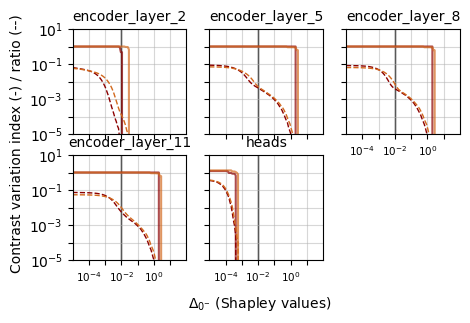

In [23]:
# plots for Shapley values
fig, ax = error_analysis.plot.plot_shapley_outs(
    vitb16_imagenet_x_shpv,
    vitb16_imagenet_y_shpv,
    vitb16_imagenet_cnt_shpv,
    shorten_vitb16_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e2,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "vitb16_imagenet_shpv_errplot.pdf"),
    bbox_inches="tight"
)

## 2. Swin-t

[[$\leftarrow$ Prev.part]](#1.-ViT-b-16) $\qquad$ [[Back to top]](#Navigation) $\qquad$ [[Next part $\to$]](#3.-MaxViT-t)

- [2.1 Set up network-specific variables](#2.1-Set-up-network-specific-variables)
- [2.2 Sobol indices](#2.2-Sobol-indices)
- [2.3 Shapley values](#2.3-Shapley-values)

### 2.1 Set up network-specific variables

[[Back to top]](#2.-Swin-t)

In [24]:
swin_t_network_name = 'swin_t'
swin_t_network_modules = [
    'features.1',
    'features.3',
    'features.5',
    'features.7',
    'head'
]

In [25]:
swin_t_imagenet_values_fnms_dict = preparation.single_unit.extract_massive_values_fnms(
    swin_t_network_name,
    values_fnm_base,
    augmentation_set_numbers_list,
    prefix=None
);



### 2.2 Sobol indices

[[Back to top]](#2.-Swin-t)

In [26]:
# load values
swin_t_imagenet_si_variances = error_analysis.retrieve.load_values(
    swin_t_imagenet_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    swin_t_network_modules,
    values_name="var",
    values_key="sitv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
swin_t_imagenet_si_values = error_analysis.retrieve.load_values(
    swin_t_imagenet_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    swin_t_network_modules,
    values_name="si+sT",
    values_key="si",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)

In [27]:
# check that all S_i <= S_i^T
for module_name in swin_t_network_modules:
    for aug_set in augmentation_set_numbers_list:
        c_values = swin_t_imagenet_si_values[module_name][aug_set]
        c_variances = swin_t_imagenet_si_variances[module_name][aug_set][0]
        c_values = np.reshape(c_values, (2, -1) + c_values.shape[1:])
        #print(c_values.shape, c_variances.shape)
        ind_high_sT = np.where(c_values[1] > 1.)
        print(module_name, aug_set, (c_values[0] > c_values[1]).any())

features.1 1 False
features.1 2 False
features.3 1 False
features.3 2 False
features.5 1 False
features.5 2 False
features.7 1 False
features.7 2 False
head 1 False
head 2 False


In [28]:
# create grids and compute statistics
swin_t_imagenet_x_si = -np.power(10, np.linspace(-5, -0.5, 100))
swin_t_imagenet_x_sT = 1 + np.power(10, np.linspace(-5, 0., 100))
(
    swin_t_imagenet_y_si,
    swin_t_imagenet_cnt_si,
    swin_t_imagenet_y_sT,
    swin_t_imagenet_cnt_sT,
) = error_analysis.retrieve.retrieve_sobol_outs(
    swin_t_imagenet_si_values,
    swin_t_imagenet_si_variances,
    swin_t_imagenet_x_si,
    swin_t_imagenet_x_sT,
    swin_t_network_modules,
    augmentation_set_numbers_list,
    #eps=1e-5
)

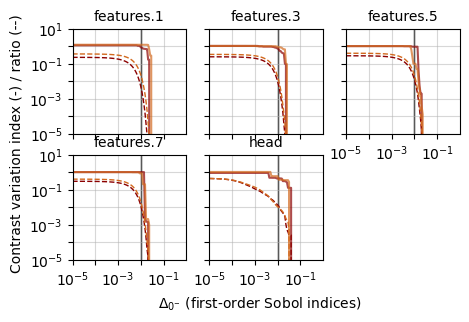

In [29]:
# plots for first-order Sobol indices
fig, ax = error_analysis.plot.plot_first_sobol_outs(
    swin_t_imagenet_x_si,
    swin_t_imagenet_y_si,
    swin_t_imagenet_cnt_si,
    swin_t_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e0,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "swin_t_imagenet_si_errplot.pdf"),
    bbox_inches="tight"
)

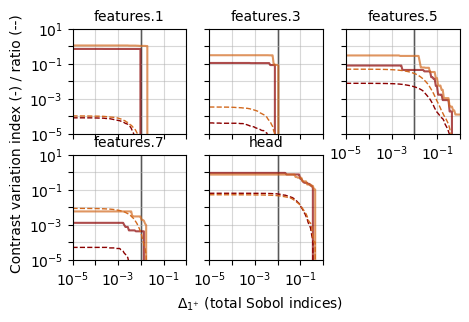

In [30]:
# plots for total Sobol indices
fig, ax = error_analysis.plot.plot_total_sobol_outs(
    swin_t_imagenet_x_sT,
    swin_t_imagenet_y_sT,
    swin_t_imagenet_cnt_sT,
    swin_t_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e0,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "swin_t_imagenet_sT_errplot.pdf"),
    bbox_inches="tight"
)

### 2.3 Shapley values

[[Back to top]](#2.-Swin-t)

In [31]:
# load values
swin_t_imagenet_shpv_values = error_analysis.retrieve.load_values(
    swin_t_imagenet_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    swin_t_network_modules,
    values_name="shpv",
    values_key="shpv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
swin_t_imagenet_shpv_variances = error_analysis.retrieve.load_values(
    swin_t_imagenet_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    swin_t_network_modules,
    values_name="var",
    values_key="shptv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
swin_t_imagenet_shpv_variances_est = dict()
for module_name in swin_t_network_modules:
    swin_t_imagenet_shpv_variances_est[module_name] = dict()
    for aug_set in augmentation_set_numbers_list:
        swin_t_imagenet_shpv_variances_est[module_name][aug_set] = np.maximum(
            swin_t_imagenet_shpv_values[module_name][aug_set].sum(axis=0), 0.
        )
        swin_t_imagenet_shpv_values[module_name][aug_set] = shpv_values_func(
            swin_t_imagenet_shpv_values[module_name][aug_set], aug_set
        )

In [32]:
# create grids and compute statistics
swin_t_imagenet_x_shpv = -np.power(10, np.linspace(-5, 2, 100))
(
    swin_t_imagenet_y_shpv,
    swin_t_imagenet_cnt_shpv
) = error_analysis.retrieve.retrieve_shapley_outs(
    swin_t_imagenet_shpv_values,
    swin_t_imagenet_shpv_variances,
    swin_t_imagenet_x_shpv,
    swin_t_network_modules,
    augmentation_set_numbers_list,
    #eps=1e-5
)

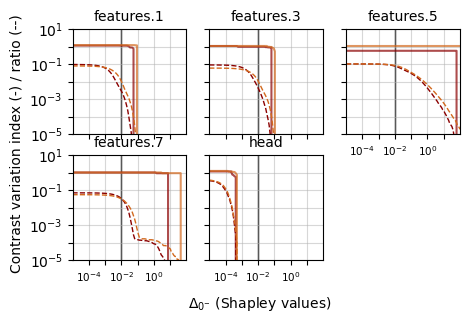

In [33]:
# plots for Shapley values
fig, ax = error_analysis.plot.plot_shapley_outs(
    swin_t_imagenet_x_shpv,
    swin_t_imagenet_y_shpv,
    swin_t_imagenet_cnt_shpv,
    swin_t_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e2,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "swin_t_imagenet_shpv_errplot.pdf"),
    bbox_inches="tight"
)

## 3. MaxViT-t

[[$\leftarrow$ Prev.part]](#2.-Swin-t) $\qquad$ [[Back to top]](#Navigation) $\qquad$

- [3.1 Set up network-specific variables](3.1-Set-up-network-specific-variables)
- [3.2 Sobol indices](#3.2-Sobol-indices)
- [3.3 Shapley values](#3.3-Shapley-values)

### 3.1 Set up network-specific variables

[[Back to top]](#3.-MaxViT-t)

In [34]:
maxvit_t_network_name = 'maxvit_t'
maxvit_t_network_modules = [
    'blocks.0',
    'blocks.1',
    'blocks.2',
    'blocks.3',
    'classifier'
]

In [35]:

maxvit_t_imagenet_values_fnms_dict = preparation.single_unit.extract_massive_values_fnms(
    maxvit_t_network_name,
    values_fnm_base,
    augmentation_set_numbers_list,
    prefix=None
);



### 3.2 Sobol indices

[[Back to top]](#3.-MaxViT-t)

In [36]:
# load values
maxvit_t_imagenet_si_variances = error_analysis.retrieve.load_values(
    maxvit_t_imagenet_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    maxvit_t_network_modules,
    values_name="var",
    values_key="sitv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
maxvit_t_imagenet_si_values = error_analysis.retrieve.load_values(
    maxvit_t_imagenet_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    maxvit_t_network_modules,
    values_name="si+sT",
    values_key="si",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)

In [37]:
# check that all S_i <= S_i^T
for module_name in maxvit_t_network_modules:
    for aug_set in augmentation_set_numbers_list:
        c_values = maxvit_t_imagenet_si_values[module_name][aug_set]
        c_variances = maxvit_t_imagenet_si_variances[module_name][aug_set][0]
        c_values = np.reshape(c_values, (2, -1) + c_values.shape[1:])
        #print(c_values.shape, c_variances.shape)
        ind_high_sT = np.where(c_values[1] > 1.)
        print(module_name, aug_set, (c_values[0] > c_values[1]).any())


blocks.0 1 False
blocks.0 2 False
blocks.1 1 False
blocks.1 2 False
blocks.2 1 False
blocks.2 2 False
blocks.3 1 False
blocks.3 2 False
classifier 1 False
classifier 2 False


In [38]:
# create grids and compute statistics
maxvit_t_imagenet_x_si = -np.power(10, np.linspace(-5, -0.5, 100))
maxvit_t_imagenet_x_sT = 1 + np.power(10, np.linspace(-5, 0., 100))
(
    maxvit_t_imagenet_y_si,
    maxvit_t_imagenet_cnt_si,
    maxvit_t_imagenet_y_sT,
    maxvit_t_imagenet_cnt_sT,
) = error_analysis.retrieve.retrieve_sobol_outs(
    maxvit_t_imagenet_si_values,
    maxvit_t_imagenet_si_variances,
    maxvit_t_imagenet_x_si,
    maxvit_t_imagenet_x_sT,
    maxvit_t_network_modules,
    augmentation_set_numbers_list,
    #eps=1e-5
)

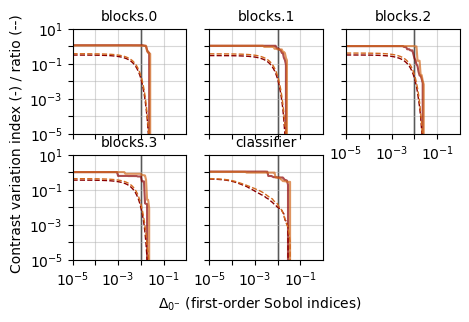

In [39]:
# plots for first-order Sobol indices
fig, ax = error_analysis.plot.plot_first_sobol_outs(
    maxvit_t_imagenet_x_si,
    maxvit_t_imagenet_y_si,
    maxvit_t_imagenet_cnt_si,
    maxvit_t_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e0,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "maxvit_t_imagenet_si_errplot.pdf"),
    bbox_inches="tight"
)

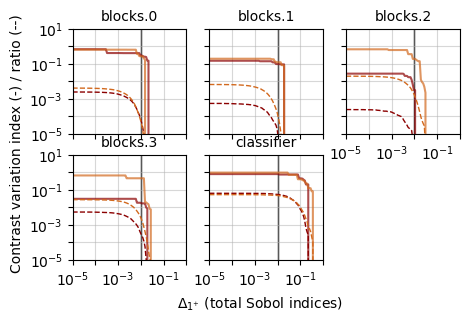

In [40]:
# plots for total Sobol indices
fig, ax = error_analysis.plot.plot_total_sobol_outs(
    maxvit_t_imagenet_x_sT,
    maxvit_t_imagenet_y_sT,
    maxvit_t_imagenet_cnt_sT,
    maxvit_t_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e0,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "maxvit_t_imagenet_sT_errplot.pdf"),
    bbox_inches="tight"
)

### 3.3 Shapley values

[[Back to top]](#3.-MaxViT-t)

In [41]:
# load values
maxvit_t_imagenet_shpv_values = error_analysis.retrieve.load_values(
    maxvit_t_imagenet_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    maxvit_t_network_modules,
    values_name="shpv",
    values_key="shpv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
maxvit_t_imagenet_shpv_variances = error_analysis.retrieve.load_values(
    maxvit_t_imagenet_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    maxvit_t_network_modules,
    values_name="var",
    values_key="shptv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
maxvit_t_imagenet_shpv_variances_est = dict()
for module_name in maxvit_t_network_modules:
    maxvit_t_imagenet_shpv_variances_est[module_name] = dict()
    for aug_set in augmentation_set_numbers_list:
        maxvit_t_imagenet_shpv_variances_est[module_name][aug_set] = np.maximum(
            maxvit_t_imagenet_shpv_values[module_name][aug_set].sum(axis=0), 0.
        )
        maxvit_t_imagenet_shpv_values[module_name][aug_set] = shpv_values_func(
            maxvit_t_imagenet_shpv_values[module_name][aug_set], aug_set
        )

In [42]:
# create grids and compute statistics
maxvit_t_imagenet_x_shpv = -np.power(10, np.linspace(-5, 2, 100))
(
    maxvit_t_imagenet_y_shpv,
    maxvit_t_imagenet_cnt_shpv
) = error_analysis.retrieve.retrieve_shapley_outs(
    maxvit_t_imagenet_shpv_values,
    maxvit_t_imagenet_shpv_variances,
    maxvit_t_imagenet_x_shpv,
    maxvit_t_network_modules,
    augmentation_set_numbers_list,
    #eps=1e-5
)

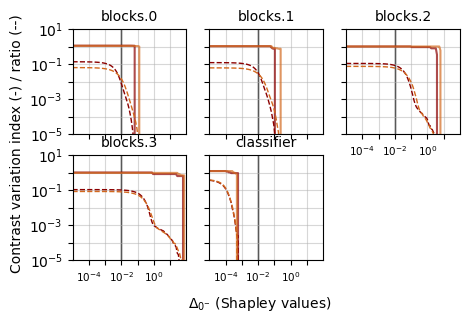

In [43]:
# plots for Shapley values
fig, ax = error_analysis.plot.plot_shapley_outs(
    maxvit_t_imagenet_x_shpv,
    maxvit_t_imagenet_y_shpv,
    maxvit_t_imagenet_cnt_shpv,
    maxvit_t_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e2,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "maxvit_t_imagenet_shpv_errplot.pdf"),
    bbox_inches="tight"
)

In [2]:
import warnings
warnings.filterwarnings("ignore")